# Geometry Of Data Homework 2
## Geodesics and Manifold Statistics
### By: Sravanth Chowdary Potluri und5uv

# Problem 1
### Geodesic Equation on $S^2$

### Problem

Consider the standard $(\theta, \phi)$ parameterization of the sphere:

$$
s: (0, 2\pi) \times \left( -\frac{\pi}{2}, \frac{\pi}{2} \right) \to \mathbb{R}^3 $$

$$
s(\theta, \phi) = (\cos\theta \cos\phi, \sin\theta \cos\phi, \sin\phi).
$$

1. **Write down equations for the coordinate tangent vectors** $ \frac{\partial s}{\partial \theta} $ **and** $ \frac{\partial s}{\partial \phi} $. These should be vectors in $ \mathbb{R}^3 $ that are functions of $ \theta, \phi $.

2. **Using the induced metric of** $ \mathbb{R}^3 $, **write down the coefficients of the Riemannian metric**, $ g $, **on** $ S^2 $ **in terms of the coordinates** $ \theta, \phi $.
   
   Hint: You should end up with a $ 2 \times 2 $ matrix, whose entries are just Euclidean $ \mathbb{R}^3 $ inner products of the tangent vectors from the previous part.

3. **Compute the inverse metric** $ g^{-1} $. Again, this will be a $ 2 \times 2 $ matrix whose entries are functions of $ \theta, \phi $.

4. **Compute formulas for the Christoffel symbols**, $ \Gamma^k_{ij} $.

5. **Show that the equator circle** $ \gamma(t) = s(t, 0) $ **is a geodesic**.

6. **Provide an argument that all great circles (circles on** $ S^2 $ **with radius = 1) are geodesics**. You don’t need a lengthy or precise proof, just a brief and informal argument will suffice.


#### The solution to the problem 1 is available in the onedrive link below
[Problem 1 Solution](https://myuva-my.sharepoint.com/:b:/g/personal/und5uv_virginia_edu/EZxLjMg7TZ5JlMluZhurtOIBdxvX5DoYHdwCsoUAlnKoMw?e=1uXejW)

# Problem 2
### Statistics On Shape Manifolds

In [2]:
# importing the required libraries

import numpy as np
import matplotlib.pyplot as plt

#### Method 1:
Project an object onto the preshape sphere by removing its centroid and scaling it to unit
norm. This is a preprocessing step that all objects will go through before applying any of the
following routines.

In [3]:
def project_to_preshape(X):
    """
    Project a shape onto the preshape sphere by centering and scaling.

    Parameters:
    X : np.ndarray
        2 x n array representing the shape.

    Returns:
    X_preshape : np.ndarray
        2 x n array representing the preshape.
    """
    # Center the shape
    centroid = np.mean(X, axis=1, keepdims=True)
    X_centered = X - centroid
    # Scale to unit norm
    norm = np.linalg.norm(X_centered)
    X_preshape = X_centered / norm
    return X_preshape

#### Method 2:
Perform Ordinary (a.k.a. Orthogonal) Procrustes Analysis (OPA). This should input a target
preshape and moving preshape and output the aligned version of the moving preshape.

In [4]:
def opa(target, moving):
    """
    Perform Ordinary Procrustes Analysis to align moving shape to target shape.

    Parameters:
    target : np.ndarray
        2 x n array representing the target preshape.
    moving : np.ndarray
        2 x n array representing the moving preshape.

    Returns:
    moving_aligned : np.ndarray
        2 x n array representing the aligned moving preshape.
    """
    # Compute the optimal rotation matrix
    
    # A = moving, B = target
    A = moving
    B = target
    
    # Compute the optimal rotation matrix
    M = B @ A.T
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt
    
    # get the aligned moving shape by the product of the rotation matrix with the moving shape
    moving_aligned = R @ moving
    return moving_aligned

#### Method 3:
Compute the exponential map on Kendall shape space, i.e., given a preshape and tangent
vector, compute the preshape at the end of the corresponding geodesic.

In [5]:
def exp_map(p, v):
    """
    Compute the exponential map on Kendall shape space.

    Parameters:
    p : np.ndarray
        2 x n array representing the preshape (base point).
    v : np.ndarray
        2 x n array representing the tangent vector at p.

    Returns:
    q : np.ndarray
        2 x n array representing the preshape at the end of the geodesic.
    """
    # Ensure v is tangent to the sphere at p
    v = v - (p.flatten() @ v.flatten()) * p
    norm_v = np.linalg.norm(v)
    if norm_v < 1e-8:
        return p
    else:
        q = np.cos(norm_v) * p + np.sin(norm_v) * (v / norm_v)
        # here np.cos(norm_v) * p is the parallel component of q to p
        # np.sin(norm_v) * (v / norm_v) is the perpendicular component of q to p
        # we get the new preshape point by adding the parallel and perpendicular components
        return q

#### Method 4:
Compute the log map on Kendall shape space, i.e., given two preshapes, compute the tangent
vector at the first preshape that is the initial condition of the geodesic segment between the
two.

In [6]:
def log_map(p, q):
    """
    Compute the logarithm map on Kendall shape space.

    Parameters:
    p : np.ndarray
        2 x n array representing the base preshape.
    q : np.ndarray
        2 x n array representing the target preshape.

    Returns:
    v : np.ndarray
        2 x n array representing the tangent vector at p pointing towards q.
    """
    # Step 1: Align q to p using OPA
    # we align q to p using OPA because the geodesic on the kendall shape space is the shortest path between two points(shapes) which have been aligned rotationally and translationally.
    q_aligned = opa(p, q)

    # Step 2: Compute the inner product between p and the aligned q
    inner_prod = p.flatten() @ q_aligned.flatten()
    inner_prod = np.clip(inner_prod, -1.0, 1.0)  # Ensure numerical stability since cos(theta) is in [-1, 1]

    # Step 3: Calculate the angular distance (theta) between p and aligned q
    # this theta is the length of the geodesic on the sphere since the distance on a sphere is the angle
    theta = np.arccos(inner_prod)

    # Step 4: Compute the tangent vector (v)
    if theta < 1e-8:
        v = np.zeros_like(p)
        # if theta is very small, the tangent vector is zero so we return a zero vector
    else:
        v = ((q_aligned - inner_prod * p)/np.sin(theta)) * theta
        # here q_aligned - inner_prod * p is the perpendicular component of q_aligned to p
        # we divide by sin(theta) to normalize the vector and make it a unit vector containing the direction
        # finally we multiply by theta to get the tangent vector since theta is the length of the geodesic on the unit sphere because radius of the sphere is 1 and distance on a sphere is the angle multiplied by the radius.

    return v

#### Method 5:
Estimate the Frechet mean shape using gradient descent as described in class.

In [7]:
def frechet_mean(shapes, max_iter=100, tol=1e-6):
    """
    Estimate the Fréchet mean of a set of preshapes using gradient descent.

    Parameters:
    shapes : list of np.ndarray
        List of 2 x n arrays representing the preshapes.
    max_iter : int
        Maximum number of iterations.
    tol : float
        Tolerance for convergence.

    Returns:
    mean_shape : np.ndarray
        2 x n array representing the estimated mean preshape.
    """
    # Initialize the mean shape
    mean_shape = shapes[0]
    for i in range(max_iter):
        # Compute tangent vectors from mean to all shapes
        vs = [log_map(mean_shape, s) for s in shapes]
        # Compute average tangent vector
        v_mean = sum(vs) / len(shapes)
        norm_v_mean = np.linalg.norm(v_mean)
        
        # Check for convergence (norm of the average tangent vector) if it is less than the tolerance
        if norm_v_mean < tol:
            print(f'Converged at iteration {i}')
            break
            
        # Updating the  mean shape
        mean_shape = exp_map(mean_shape, v_mean)
        
    return mean_shape

#### Method 6:
Compute the approximate principal geodesic analysis (PGA), that is, perform principal com-
ponent analysis (PCA) in the tangent space to the Fr´echet mean.

In [8]:
def pga(shapes, mean_shape):
    """
    Perform Principal Geodesic Analysis on the tangent space at the mean shape.

    Parameters:
    shapes : list of np.ndarray
        List of 2 x n arrays representing the preshapes.
    mean_shape : np.ndarray
        2 x n array representing the mean preshape.

    Returns:
    eigvals : np.ndarray
        Array of eigenvalues.
    eigvecs : np.ndarray
        Array of eigenvectors (principal directions), shape (2n, k).
    """
    # getting U by applying log map to all shapes and stacking them to get a matrix that has the values of the tangent vector from the mean shape to all shapes. This matrix contains the values of the tangent vectors for all shapes for every cooordinate of every point in the shape
    U = np.array([log_map(mean_shape, s).flatten() for s in shapes]).T
    
    # Compute S matrix by taking the covariance of U
    S = np.cov(U)

    # Perform eigenvalue decomposition on S
    eigvals, eigvecs = np.linalg.eigh(S)
    
    # Sort in descending order to get the principal directions
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    return eigvals, eigvecs

### Experiment
Random triangles. Generate a set of 100 triangles with the following three points:
$$p0 = (−1,0), p1 = (1,0), p2 = (0,s)$$
where s is a Gaussian random variable with mean 1 and standard deviation 0.5. Next, add
zero-mean Gaussian noise with s.d. 0.1 to all six coordinates of each of the 100 triangles.


#### Helper functions

In [9]:
def generate_random_triangles(num_samples=100):
    """
    Generate a set of random triangles as specified in the assignment.

    Parameters:
    num_samples : int
        Number of triangles to generate.

    Returns:
    shapes : list of np.ndarray
        List of 2 x 3 arrays representing the triangles.
    """
    shapes = []
    for _ in range(num_samples):
        # s ~ N(1, 0.5^2)
        s = np.random.normal(1, 0.5)
        p0 = np.array([-1, 0])
        p1 = np.array([1, 0])
        p2 = np.array([0, s])
        X = np.column_stack((p0, p1, p2))
        # Add Gaussian noise with s.d. 0.1 to all coordinates
        noise = np.random.normal(0, 0.1, X.shape)
        X_noisy = X + noise
        shapes.append(X_noisy)
    return shapes

def plot_shape(X, ax=None, **kwargs):
    """
    Plot a shape represented by a 2 x n array.

    Parameters:
    X : np.ndarray
        2 x n array representing the shape.
    ax : matplotlib.axes.Axes
        Axes object to plot on.
    kwargs : dict
        Additional arguments passed to plot.
    """
    if ax is None:
        ax = plt.gca()
    X = np.hstack((X, X[:, [0]]))  # Close the shape by adding the first point at the end
    ax.plot(X[0, :], X[1, :], **kwargs)

#### Generating the dataset

In [10]:
shapes_raw = generate_random_triangles(100)

In [11]:
# Project to preshape sphere by removing the centroid and scaling to unit norm
shapes_preshape = [project_to_preshape(X) for X in shapes_raw]

# Estimate the Fréchet mean
mean_shape = frechet_mean(shapes_preshape)

# Aligning all shapes to the mean shape
shapes_aligned = [opa(mean_shape, s) for s in shapes_preshape]

# Perform PGA
# we perform PGA on the aligned shapes so as to ensure the PGA is performed in the kendall shape space i.e after aligning the shapes rotationally and translationally
eigvals, eigvecs = pga(shapes_aligned, frechet_mean(shapes_aligned))

Converged at iteration 4
Converged at iteration 4


#### Experiment 1:
Pick two objects from the data set and plot a geodesic between them (this should be a
sequence of objects deforming from one to the other).

Here we pick 2 random shapes from the aligned shapes and plot a geodesic between them to show the deformation from one shape to the other. Here we are choosing aligned shapes dataset so that we need not perform any preprocessing steps like projecting to preshape sphere or aligning the shapes to the mean shape.

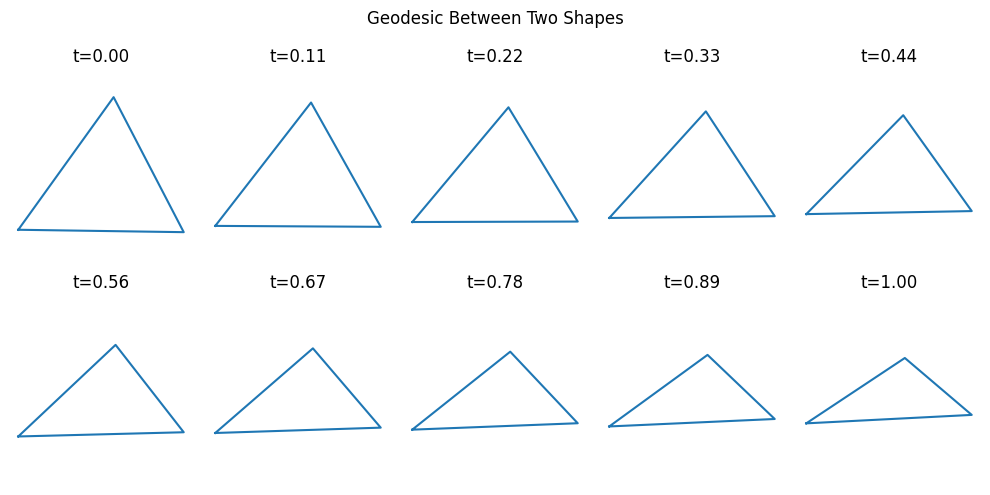

In [12]:
# Plot geodesic between two random aligned shapes
# getting 2 random numbers to pick 2 random shapes from the aligned shapes dataset

random_1 = np.random.randint(0, len(shapes_aligned))
random_2 = np.random.randint(0, len(shapes_aligned))

shape1 = shapes_aligned[random_1]
shape2 = shapes_aligned[random_2]

num_steps = 10
t_vals = np.linspace(0, 1, num_steps)
geodesic_shapes = [exp_map(shape1, t * log_map(shape1, shape2)) for t in t_vals]

plt.figure(figsize=(10, 5))
for i, shape in enumerate(geodesic_shapes):
    plt.subplot(2, 5, i+1)
    plot_shape(shape)
    plt.title(f't={t_vals[i]:.2f}')
    plt.axis('equal')
    plt.axis('off')
plt.suptitle('Geodesic Between Two Shapes')
plt.tight_layout()
plt.show()

#### Animation of the geodesic

In [13]:
import numpy as np
import plotly.graph_objs as go

num_steps = 100
t_vals = np.linspace(0, 1, num_steps)
geodesic_shapes = [exp_map(shape1, t * log_map(shape1, shape2)) for t in t_vals]

# Function to ensure the shape is closed by adding the first point to the end
def close_shape(shape):
    return np.hstack([shape, shape[:, [0]]])

# Create frames for each step in the geodesic
frames = []
for i, shape in enumerate(geodesic_shapes):
    closed_shape = close_shape(shape)  # Close the shape by connecting the last point to the first
    frames.append(go.Frame(data=[go.Scatter(x=closed_shape[0], y=closed_shape[1], mode='lines+markers')],
                           layout=go.Layout(title_text=f't={t_vals[i]:.2f}')))

# Create the initial plot
closed_shape_initial = close_shape(geodesic_shapes[0])
fig = go.Figure(
    data=[go.Scatter(x=closed_shape_initial[0], y=closed_shape_initial[1], mode='lines+markers')],
    layout=go.Layout(
        xaxis=dict(range=[-1, 2], autorange=False),
        yaxis=dict(range=[-1, 2], autorange=False),
        title="Geodesic Between Two Shapes",
        updatemenus=[dict(type="buttons", showactive=False,
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, {"frame": {"duration": 50, "redraw": True},
                                                     "fromcurrent": True, "mode": "immediate"}])])],
    ),
    frames=frames
)

# Show the plot
fig.show()


#### Click on the play button to see the animation of the geodesic between the two shapes by seeing the deformation from one shape to the other.

#### Experiment 2:
Plots of 1) the raw object data (i.e., all points from all objects overlaid in one plot), 2)
the preshapes aligned to the Fr´echet mean, and 3) the Frechet mean shape (in a different
color). Can you see an obvious difference in the aligned shapes?


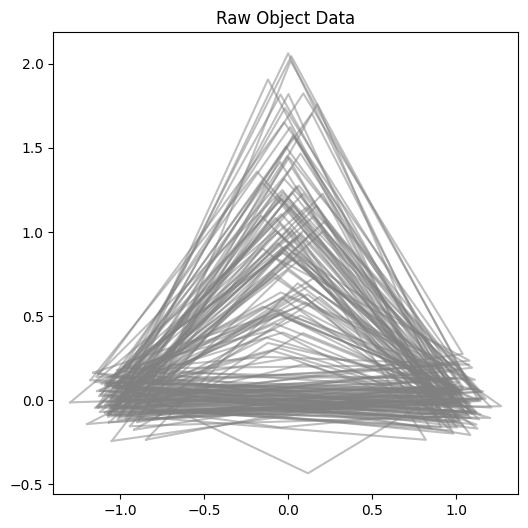

Converged at iteration 4


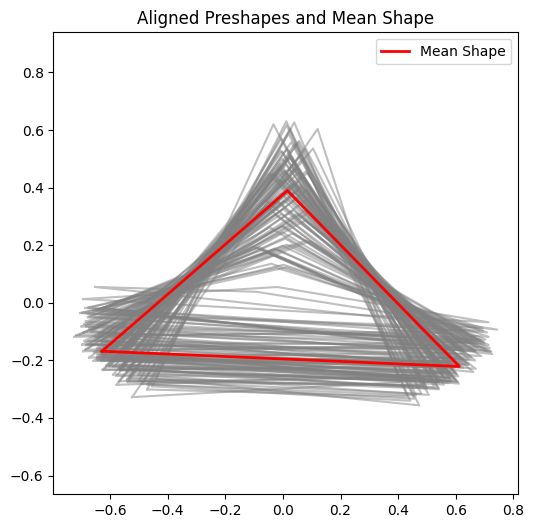

In [14]:
# Experiment 2: Plot raw object data
plt.figure(figsize=(6,6))
for X in shapes_raw:
    plot_shape(X, color='gray', alpha=0.5)
plt.title('Raw Object Data')
plt.axis('equal')
plt.show()

# Plot aligned preshapes and mean shape
plt.figure(figsize=(6,6))
for X in shapes_aligned:
    plot_shape(X, color='gray', alpha=0.5)
plot_shape(frechet_mean(shapes_aligned), color='red', linewidth=2, label='Mean Shape')
plt.title('Aligned Preshapes and Mean Shape')
plt.legend()
plt.axis('equal')
plt.show()

#### You can see an obvious differences in the figure with the aligned shapes. The aligned shapes are more closer to each other and are centered around the mean shape, While The raw object data is more spread out and does not have a clear structure.

#### Experiment 3:
A plot of the eigenvalues for each mode (scree plot). Looking at this plot, how many
modes would you use to describe the data?

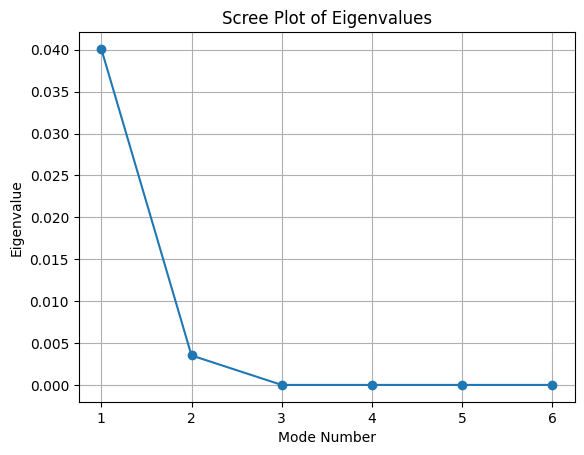

Cumulative Variance Explained: [0.91931978 1.         1.         1.         1.         1.        ]


In [15]:
# Experiment 3: Scree plot of eigenvalues
plt.figure()
plt.plot(np.arange(1, len(eigvals)+1), eigvals, 'o-')
plt.title('Scree Plot of Eigenvalues')
plt.xlabel('Mode Number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

# Decide number of modes (e.g., modes that explain significant variance)
cumulative_variance = np.cumsum(eigvals) / np.sum(eigvals)
print('Cumulative Variance Explained:', cumulative_variance)

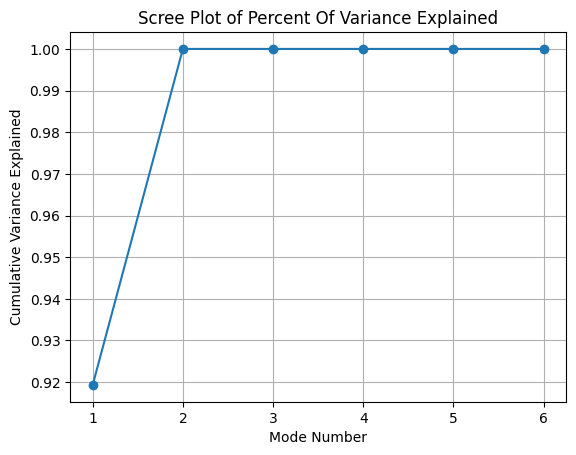

In [16]:
# Getting a scree plot of the variance explained by each mode in percentage
plt.figure()
plt.plot(np.arange(1, len(eigvals)+1), cumulative_variance, 'o-')
plt.title('Scree Plot of Percent Of Variance Explained')
plt.xlabel('Mode Number')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

#### Looking at the scree plot, we can see that only the first two eignvalues have some significance and the rest of the eigenvalues seem to be zero. So use only the first two modes to describe the data as they explain most of the variance in the data.

#### Experiment 4:
Plot the modes of variation at 0,±1,±2 standard deviations. You only need to plot up
to 3 different modes (maybe fewer, if you decided in the previous question that fewer
were needed to represent the data).


[-0.28891315  0.38070995 -0.0917968   0.39992898  0.3115273  -0.71145628]


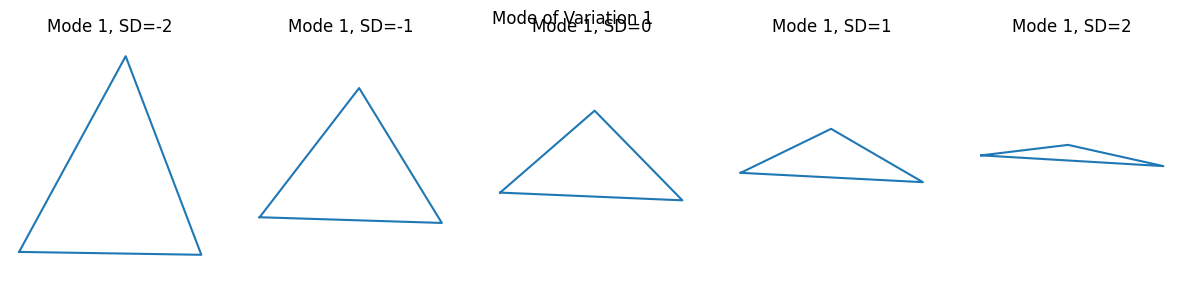

[-0.28891315  0.38070995 -0.0917968   0.39992898  0.3115273  -0.71145628]


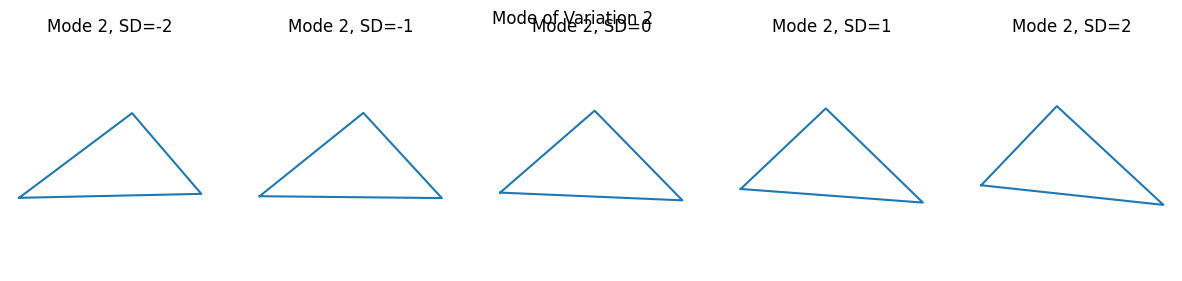

In [17]:
# Experiment 4: Plot modes of variation

# Define how many modes to plot. In this case, we're plotting 2 modes (up to 3 possible modes).
modes_to_plot = 2

# Define the standard deviations to explore the modes of variation.
# We'll explore each mode at -2, -1, 0, 1, and 2 standard deviations from the mean shape.
std_devs = [-2, -1, 0, 1, 2]

# Loop through each mode to plot its variations
for mode in range(modes_to_plot):
    
    # Get the eigenvalue corresponding to the current mode. This represents how much variance the mode explains.
    eigval = eigvals[mode]
    # Get the eigenvector corresponding to the current mode. This represents the direction of variation in shape space.
    # The eigenvector is reshaped into a 2D shape (2 x number_of_points).
    eigvec = eigvecs[:, mode].reshape(2, -1)
    print(eigvecs[:,0])
    # Compute the standard deviation (sqrt of the eigenvalue). This gives us a scaling factor to apply to the eigenvector.
    std = np.sqrt(eigval)
    # Create a figure for plotting the mode of variation
    plt.figure(figsize=(15,3))
    
    # Loop through different standard deviations to visualize how the shape changes along this mode
    for i, k in enumerate(std_devs):
        
        # Calculate the tangent vector `v` by multiplying the eigenvector by the standard deviation `k`.
        # This gives a different magnitude of variation along the mode of shape change.
        v = k * std * eigvec
        
        # Use the exponential map to project the tangent vector `v` back onto the shape space (preshape sphere).
        # This gives us the shape corresponding to this variation.
        shape = exp_map(mean_shape, v)
        
        # Plot the resulting shape at this particular standard deviation
        plt.subplot(1, len(std_devs), i+1)
        plot_shape(shape)
        
        # Add a title to indicate the standard deviation `k` used for this variation
        plt.title(f'Mode {mode+1}, SD={k}')
        
        # Ensure the plot maintains equal aspect ratio so the shape isn't distorted
        plt.axis('equal')
        
        # Turn off axis labels for clarity
        plt.axis('off')
    
    # Add a super title to the figure indicating the mode being visualized (Mode 1, Mode 2, etc.)
    plt.suptitle(f'Mode of Variation {mode+1}')
    
    # Display the figure
    plt.show()

In [18]:
print('Modes of Variation:')
for mode in range(modes_to_plot):
    eigval = eigvals[mode]
    variance_explained = eigval / np.sum(eigvals)
    print(f'Mode {mode+1}: Eigenvalue={eigval:.4f}, Variance Explained={variance_explained:.2%}')

Modes of Variation:
Mode 1: Eigenvalue=0.0401, Variance Explained=91.93%
Mode 2: Eigenvalue=0.0035, Variance Explained=8.07%


#### Experiment 5:
Describe what you are seeing in the modes of variation. For the triangle case, is this the
variation you expected?
##### In the first mode of variation we can see that the triangular shape is changing about the point p2. which seems to be the point with the most variance in the data. This is consistent with what i expected because the point p2 is set to be (0,s) where s is a gaussian random variable so there are probably many different variations at this point as we see in the raw object data. The second mode of variation shows only the base of the triangle changing slightly across deviations which is also consistent with the data as the base of the triangle is fixed at (-1,0) and (1,0) and since gaussian noise is added to the points, the base of the triangle only changes slightly across deviations in the mode 2 of variation.

## Experiment
Corpus callosum shapes: https://tomfletcher.github.io/GeometryOfData/homeworks/
cc-shapes.zip
Each corpus callosum object consists of 64 points listed in an ASCII text file. Each line of
the file contains a single point (x and y coordinates).

In [19]:
# Load corpus callosum shapes from the folder cc-shapes

import os

def load_cc_shapes(folder):
    shapes = []
    for i in range(32):
        filename = f'cc.{i:02d}.lpts'
        filepath = os.path.join(folder, filename)
        with open(filepath, 'r') as f:
            lines = f.readlines()
        X = np.array([[float(x) for x in line.strip().split()] for line in lines]).T
        shapes.append(X)
    return shapes

cc_shapes = load_cc_shapes('cc-shapes')

In [20]:
# Project to preshape sphere
cc_preshape = [project_to_preshape(X) for X in cc_shapes]

# Estimate the Fréchet mean
cc_mean_shape = frechet_mean(cc_preshape)

# Align all shapes to the mean shape
cc_aligned = [opa(cc_mean_shape, s) for s in cc_preshape]

# Perform PGA
cc_eigvals, cc_eigvecs = pga(cc_aligned, cc_mean_shape)

Converged at iteration 2


#### Experiment 1:
Pick two objects from the data set and plot a geodesic between them (this should be a
sequence of objects deforming from one to the other).

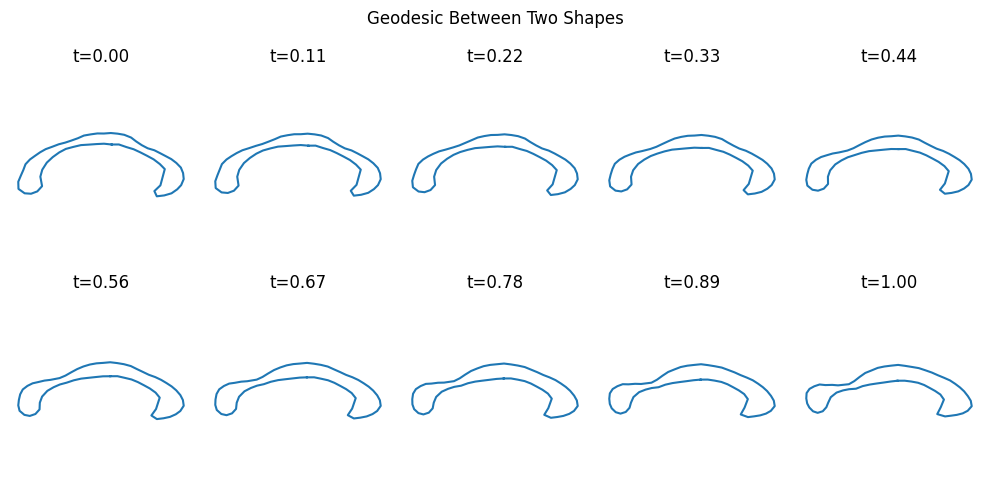

In [21]:
# Plot geodesic between two shapes
shape1 = cc_preshape[0]
shape2 = cc_preshape[1]
num_steps = 10
t_vals = np.linspace(0, 1, num_steps)
geodesic_shapes = [exp_map(shape1, t * log_map(shape1, shape2)) for t in t_vals]

plt.figure(figsize=(10, 5))
for i, shape in enumerate(geodesic_shapes):
    plt.subplot(2, 5, i+1)
    plot_shape(shape)
    plt.title(f't={t_vals[i]:.2f}')
    plt.axis('equal')
    plt.axis('off')
plt.suptitle('Geodesic Between Two Shapes')
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import plotly.graph_objs as go

num_steps = 100
t_vals = np.linspace(0, 1, num_steps)
geodesic_shapes = [exp_map(shape1, t * log_map(shape1, shape2)) for t in t_vals]

# Function to ensure the shape is closed by adding the first point to the end
def close_shape(shape):
    return np.hstack([shape, shape[:, [0]]])

# Create frames for each step in the geodesic
frames = []
for i, shape in enumerate(geodesic_shapes):
    closed_shape = close_shape(shape)  # Close the shape by connecting the last point to the first
    frames.append(go.Frame(data=[go.Scatter(x=closed_shape[0], y=closed_shape[1], mode='lines+markers')],
                           layout=go.Layout(title_text=f't={t_vals[i]:.2f}')))

# Create the initial plot
closed_shape_initial = close_shape(geodesic_shapes[0])
fig = go.Figure(
    data=[go.Scatter(x=closed_shape_initial[0], y=closed_shape_initial[1], mode='lines+markers')],
    layout=go.Layout(
        xaxis=dict(range=[-1, 2], autorange=False),
        yaxis=dict(range=[-1, 2], autorange=False),
        title="Geodesic Between Two Shapes",
        updatemenus=[dict(type="buttons", showactive=False,
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, {"frame": {"duration": 50, "redraw": True},
                                                     "fromcurrent": True, "mode": "immediate"}])])],
    ),
    frames=frames
)

# Show the plot
fig.show()


#### Click on the play button to see the animation of the geodesic between the two shapes by seeing the deformation from one shape to the other. Also please use the select tool to zoom in and see the deformation more clearly.

#### Experiment 2:
Plots of 1) the raw object data (i.e., all points from all objects overlaid in one plot), 2)
the preshapes aligned to the Fr´echet mean, and 3) the Frechet mean shape (in a different
color). Can you see an obvious difference in the aligned shapes?

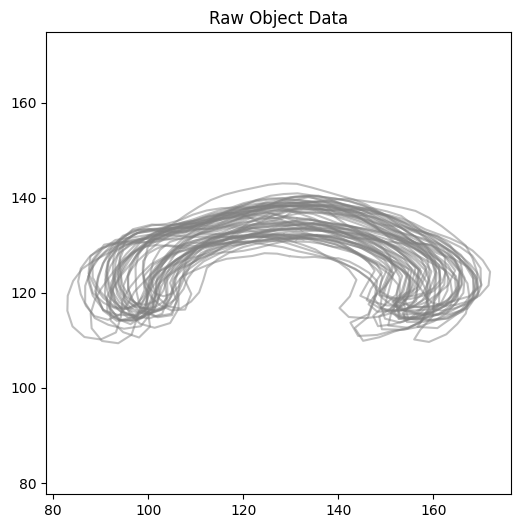

Converged at iteration 2


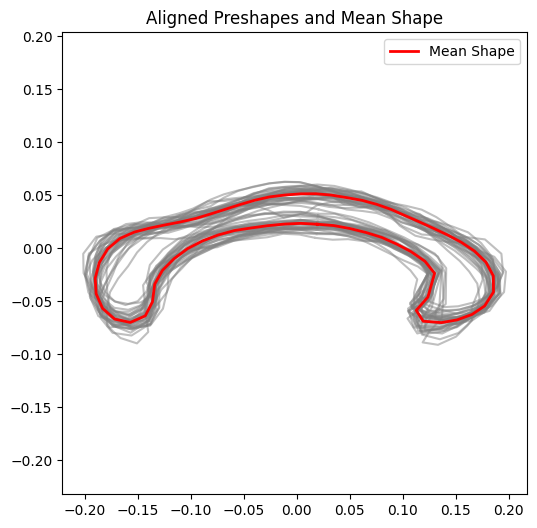

In [23]:
# Plot raw object data
plt.figure(figsize=(6,6))
for X in cc_shapes:
    plot_shape(X, color='gray', alpha=0.5)
plt.title('Raw Object Data')
plt.axis('equal')
plt.show()

# Plot aligned preshapes and mean shape
plt.figure(figsize=(6,6))
for X in cc_aligned:
    plot_shape(X, color='gray', alpha=0.5)
plot_shape(frechet_mean(cc_aligned), color='red', linewidth=2, label='Mean Shape')
plt.title('Aligned Preshapes and Mean Shape')
plt.legend()
plt.axis('equal')
plt.show()

#### You can see an obvious differences in the figure with the aligned shapes. The aligned shapes are more closer to each other and are centered around the mean shape, While The raw object data is more spread out and does not have a clear structure.

#### Experiment 3:
A plot of the eigenvalues for each mode (scree plot). Looking at this plot, how many
modes would you use to describe the data?

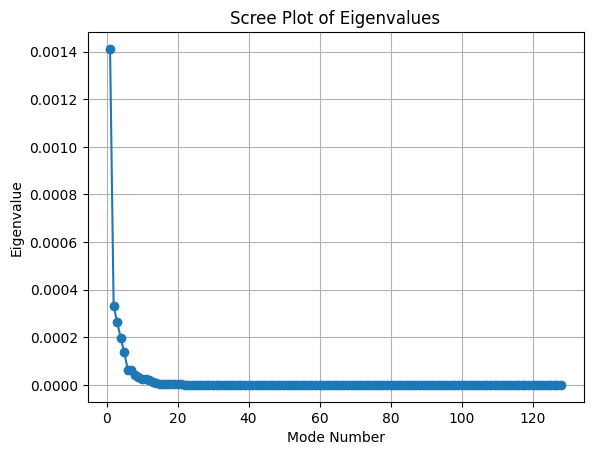

Cumulative Variance Explained: [0.52878361 0.653401   0.75218224 0.82617536 0.87722274 0.90094486
 0.92394495 0.93899745 0.95115677 0.96095727 0.97030504 0.97754097
 0.98187911 0.9855236  0.98774691 0.98991261 0.99171416 0.99339047
 0.99485275 0.99585463 0.99665036 0.99729501 0.997796   0.99825174
 0.99865904 0.99896562 0.9992513  0.99950051 0.99971699 0.99987201
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.        

In [24]:
# Scree plot of eigenvalues
plt.figure()
plt.plot(np.arange(1, len(cc_eigvals)+1), cc_eigvals, 'o-')
plt.title('Scree Plot of Eigenvalues')
plt.xlabel('Mode Number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

# Decide number of modes (e.g., modes that explain significant variance)
cumulative_variance = np.cumsum(cc_eigvals) / np.sum(cc_eigvals)
print('Cumulative Variance Explained:', cumulative_variance)

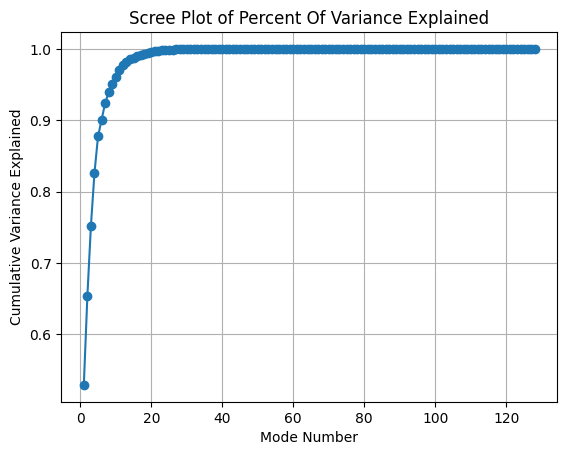

In [25]:
# Getting a scree plot of the variance explained by each mode in percentage
plt.figure()
plt.plot(np.arange(1, len(cc_eigvals)+1), cumulative_variance, 'o-')
plt.title('Scree Plot of Percent Of Variance Explained')
plt.xlabel('Mode Number')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

#### Looking at the scree plot and the explained variance, we can see that the first 10 eigenvalues explain upto more that 95% of the variance in the data. However we use only the first 3 modes to describe the data as they explain a significant amount of variance in the data.

#### Experiment 4:
Plot the modes of variation at 0,±1,±2 standard deviations. You only need to plot up
to 3 different modes (maybe fewer, if you decided in the previous question that fewer
were needed to represent the data).

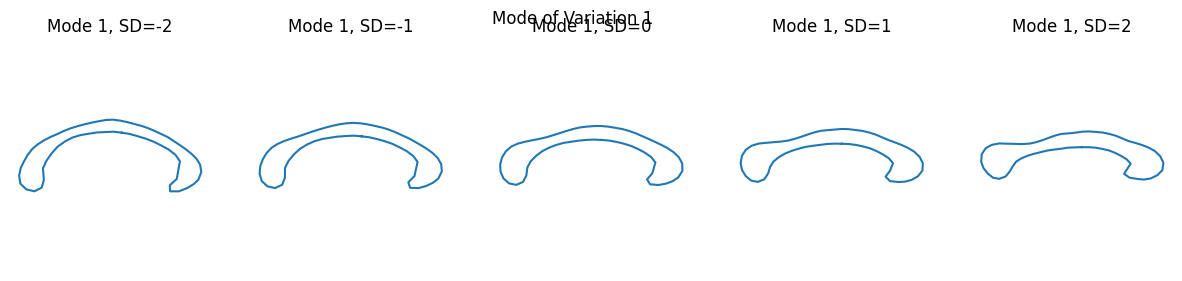

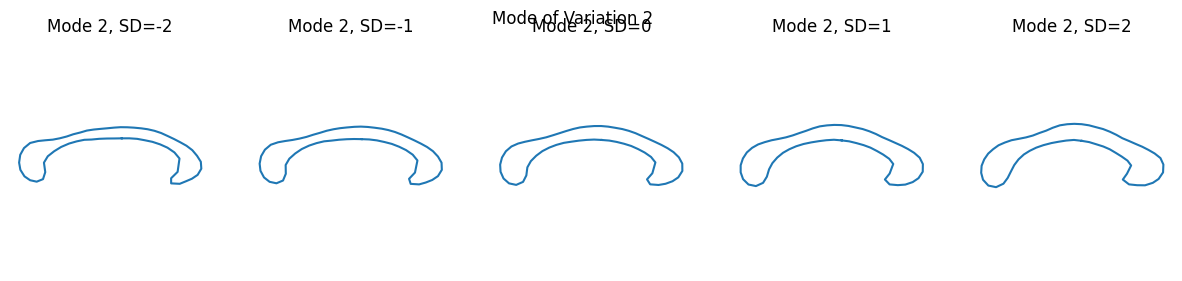

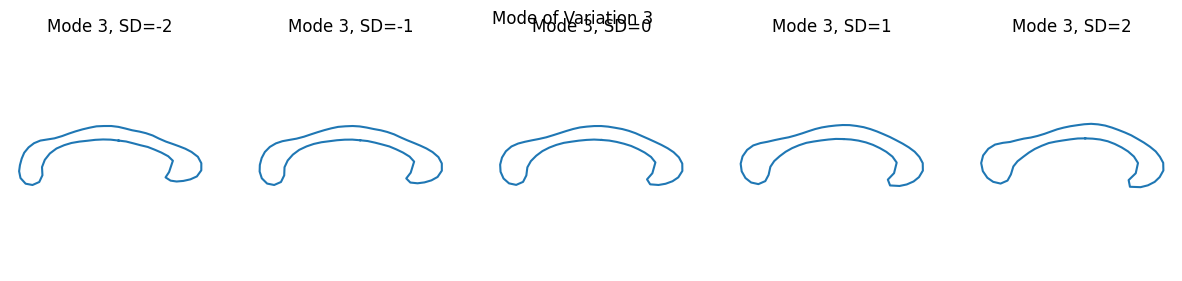

In [26]:
# Experiment 4: Plot modes of variation

# Define how many modes to plot. In this case, we're plotting 2 modes (up to 3 possible modes).
modes_to_plot = 3

# Define the standard deviations to explore the modes of variation.
# We'll explore each mode at -2, -1, 0, 1, and 2 standard deviations from the mean shape.
std_devs = [-2, -1, 0, 1, 2]

# Loop through each mode to plot its variations
for mode in range(modes_to_plot):
    
    # Get the eigenvalue corresponding to the current mode. This represents how much variance the mode explains.
    eigval = cc_eigvals[mode]
    
    # Get the eigenvector corresponding to the current mode. This represents the direction of variation in shape space.
    # The eigenvector is reshaped into a 2D shape (2 x number_of_points).
    eigvec = cc_eigvecs[:, mode].reshape(2, -1)
    
    # Compute the standard deviation (sqrt of the eigenvalue). This gives us a scaling factor to apply to the eigenvector.
    # without the scaling factor, the vector could be way too large and can produce shapes that are not meaningful.
    std = np.sqrt(eigval)
    
    # Create a figure for plotting the mode of variation
    plt.figure(figsize=(15,3))
    
    # Loop through different standard deviations to visualize how the shape changes along this mode
    for i, k in enumerate(std_devs):
        
        # Calculate the tangent vector `v` by multiplying the eigenvector by the standard deviation `k`.
        # This gives a different magnitude of variation along the mode of shape change.
        v = k * std * eigvec
        
        # Use the exponential map to project the tangent vector `v` back onto the shape space (preshape sphere).
        # This gives us the shape corresponding to this variation.
        shape = exp_map(cc_mean_shape, v)
        
        # Plot the resulting shape at this particular standard deviation
        plt.subplot(1, len(std_devs), i+1)
        plot_shape(shape)
        
        # Add a title to indicate the standard deviation `k` used for this variation
        plt.title(f'Mode {mode+1}, SD={k}')
        
        # Ensure the plot maintains equal aspect ratio so the shape isn't distorted
        plt.axis('equal')
        
        # Turn off axis labels for clarity
        plt.axis('off')
    
    # Add a super title to the figure indicating the mode being visualized (Mode 1, Mode 2, etc.)
    plt.suptitle(f'Mode of Variation {mode+1}')
    
    # Display the figure
    plt.show()

#### Experiment 5:
Describe what you are seeing in the modes of variation. For the triangle case, is this the
variation you expected?

#### In the 3 modes of variation shown above, we can see that shapes are changing some of the feature that they have across the deviations. In the first mode we see that the shape is changing decreasing the volume in the outside of the concavity of the curve. Similarly you can see the different modes changing the shape in different ways across the deviations.

In [27]:
# Print modes of variation
print('Modes of Variation:')
for mode in range(modes_to_plot):
    eigval = cc_eigvals[mode]
    variance_explained = eigval / np.sum(cc_eigvals)
    print(f'Mode {mode+1}: Eigenvalue={eigval:.4f}, Variance Explained={variance_explained:.2%}')

Modes of Variation:
Mode 1: Eigenvalue=0.0014, Variance Explained=52.88%
Mode 2: Eigenvalue=0.0003, Variance Explained=12.46%
Mode 3: Eigenvalue=0.0003, Variance Explained=9.88%


#### Discuss: What is the maximal number of modes that are possible for triangle shapes? In general, what are the maximal number of modes that are possible for a set of objects with n points?

#### Maximal Number of Modes for Triangle Shapes:

For a triangle, which consists of 3 points in 2D space, the initial number of degrees of freedom (DOF) is 6 (since each point has 2 coordinates). After removing the effects of translation (2 DOF), rotation (1 DOF), and scaling (1 DOF), there are 2 degrees of freedom left. These 2 DOF correspond to the 2 independent modes of variation for triangle shapes in Kendall’s shape space. This is consistent with the results obtained from the PCA analysis, where the first 2 eigenvalues explained all of the variance in the data.

#### Maximal Number of Modes for Objects with n Points:

For a general shape with  n  points in 2D space, the total number of degrees of freedom is  2n  (since each point has 2 coordinates). After accounting for translation (2 DOF), rotation (1 DOF), and scaling (1 DOF), the remaining degrees of freedom are  2n - 4 . Thus, the maximal number of modes of variation for a set of  n -point objects in 2D space is  2n - 4 , representing the independent ways the shape can vary.

Even though Principal Geodesic Analysis (PGA) produces  2n  eigenvalues, only  2n - 4  of them correspond to meaningful shape variations, as the other 4 represent rigid transformations (translation, rotation, and scaling).

This is pretty clear from the complex numbered data structure that can be used to represent the shape space. Intially the space has k points, but after removing effect of translation it becomes a k-1 dimension projective space. After removing the effect of rotation and scale, it becomes a k-2 dimension projective space. in the data structure we used, which has twice the number of dimensions when compared to the complex number representation, we see that the maximal number of modes that are possible for a set of objects with n points is 2n-4 analogous to the complex number representation.

#### Challenges Faced

1. Had to understand log map and exp map clearly and how to use them along with OPAs to align the shapes to project them to kendall shape space.
2. Had to try to derive expressions for logmap and expmap on the sphere of kendall shape space. Took a bit of time.
3. Had to understand the concept of PGA and it's tangent approximation and how it is different from conventional PCA, by using the logmap and frechet mean.
4. Even though ChatGPT and Github Copilot and the references helped a lot, it was still challenging to implement the functions and understand the concepts clearly. Since they ended up giving me incorrect solutions, I had to rely on the the course material to understand the concepts and implement the functions.

##### Programming Assisted By ChatGPT and Github Copilot

#### References:
1. [Geometry of Data Course](https://tomfletcher.github.io/GeometryOfData/)
2. [Kendall, 1984](http://image.diku.dk/imagecanon/material/kendall-shapes.pdf)